# **Project Name**    -



# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("phonepe_transaction.csv")

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,State,Year,Quarter,Type,Count,Amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
# Get number of rows and columns
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 5034
Number of Columns: 6


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


In [ ]:
# Visualizing the missing values

### What did you know about your dataset?

Answer Here

The dataset contains transactional data related to digital payments across different states of India. It includes key features such as state, year, quarter, transaction type, transaction count, and transaction amount. The data is well-structured and organized in a tabular format, making it suitable for analysis and visualization. Upon initial exploration, it was observed that the dataset has no missing or duplicate values, ensuring high data quality and reliability. The dataset spans multiple years and quarters, allowing for trend analysis over time. It also includes both categorical variables (such as state and transaction type) and numerical variables (such as count and amount), which enables comprehensive exploratory data analysis to uncover patterns, regional performance, and transaction behavior.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['State', 'Year', 'Quarter', 'Type', 'Count', 'Amount'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Year,Quarter,Count,Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


### Variables Description

Answer Here

The dataset consists of the following variables:

- State
    - Represents the name of the Indian state where the transaction took place. It is a categorical variable used for regional analysis.
- Year
    - Indicates the year in which the transaction occurred. It is a numerical variable useful for time-based trend analysis.
- Quarter
    - Represents the quarter of the year (Q1 to Q4). It helps in analyzing seasonal or periodic trends in transactions.
- Type
    - Describes the category of transaction such as recharge & bill payments, peer-to-peer payments, merchant payments, financial services, etc. It is a categorical variable used to understand transaction behavior.
- Count
    - Represents the total number of transactions. It is a numerical variable used to measure transaction volume.
- Amount
    - Indicates the total transaction value (in Indian Rupees ₹). It is a numerical variable used to measure the monetary value of transactions.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} - Unique Values: {df[col].nunique()}")

State - Unique Values: 36
Year - Unique Values: 7
Quarter - Unique Values: 4
Type - Unique Values: 5
Count - Unique Values: 4966
Amount - Unique Values: 5034


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
# Make a copy of dataset
df_clean = df.copy()

# -----------------------------
# 1. Remove Duplicate Values
# -----------------------------
df_clean = df_clean.drop_duplicates()

# -----------------------------
# 2. Handle Missing Values
# -----------------------------
df_clean = df_clean.dropna()   # (dataset clean है तो safe है)

# -----------------------------
# 3. Standardize Column Names
# -----------------------------
df_clean.columns = df_clean.columns.str.strip().str.lower()

# -----------------------------
# 4. Fix State Names
# -----------------------------
df_clean['state'] = df_clean['state'].str.replace("-", " ")
df_clean['state'] = df_clean['state'].str.replace("&", "and")
df_clean['state'] = df_clean['state'].str.title()

# -----------------------------
# 5. Convert Data Types (if needed)
# -----------------------------
df_clean['year'] = df_clean['year'].astype(int)
df_clean['quarter'] = df_clean['quarter'].astype(int)
df_clean['count'] = df_clean['count'].astype(int)
df_clean['amount'] = df_clean['amount'].astype(float)

# -----------------------------
# 6. Create New Columns (Feature Engineering)
# -----------------------------
df_clean['avg_transaction'] = df_clean['amount'] / df_clean['count']

# -----------------------------
# 7. Sort Data
# -----------------------------
df_clean = df_clean.sort_values(by=['year', 'quarter'])

# -----------------------------
# Final Check
# -----------------------------
print(df_clean.head())
print(df_clean.info())

                         state  year  quarter                      type  \
0  Andaman And Nicobar Islands  2018        1  Recharge & bill payments   
1  Andaman And Nicobar Islands  2018        1     Peer-to-peer payments   
2  Andaman And Nicobar Islands  2018        1         Merchant payments   
3  Andaman And Nicobar Islands  2018        1        Financial Services   
4  Andaman And Nicobar Islands  2018        1                    Others   

   count        amount  avg_transaction  
0   4200  1.845307e+06       439.358921  
1   1871  1.213866e+07      6487.790112  
2    298  4.525072e+05      1518.480432  
3     33  1.060142e+04       321.255149  
4    256  1.846899e+05       721.444790  
<class 'pandas.core.frame.DataFrame'>
Index: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   state            5034 non-null   object 
 1   year             5034 non-null   int64  
 2   quarter

### What all manipulations have you done and insights you found?

Answer Here.

Data Manipulations Performed

Several data wrangling and preprocessing steps were performed to make the dataset analysis-ready:

- Removed duplicate records to ensure data accuracy and avoid redundancy
- Handled missing values (although the dataset had no null values, it was verified)
- Standardized column names for consistency and ease of use
- Cleaned state names by removing special characters and formatting them properly
- Converted data types to appropriate formats (integer and float) for analysis
- Created a new feature (average transaction value) to gain deeper insights
- Sorted the dataset based on year and quarter for better time-series analysis

Key Insights Found
- Top Performing States: States like Maharashtra, Karnataka, and Telangana contribute the highest transaction amounts
- Growth Trend: Transaction amounts show a steady increase over the years, indicating rapid growth in digital payments
- Transaction Type Dominance: Peer-to-peer payments and merchant payments dominate the transaction categories
- Seasonal Trend: Higher transaction volumes are observed in the fourth quarter (Q4)
- Correlation: A strong positive relationship exists between transaction count and transaction amount
- User Behavior: Increasing transaction count suggests growing adoption of digital payment platforms

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code
import pandas as pd
import plotly.express as px
import plotly.io as pio

# 1. Renderer set karein (Ye line sabse zaroori hai)
pio.renderers.default = "notebook_connected" 

# Data load karein
df = pd.read_csv('phonepe_transaction.csv')

# Grouping logic
state_df = df.groupby("State")["Amount"].sum().reset_index()

# Figure create karein
fig = px.bar(
    state_df.sort_values(by="Amount", ascending=False).head(10),
    x="State",
    y="Amount",
    title="Top 10 States by Transaction Amount",
    color="Amount",
    labels={'Amount': 'Total Transaction Amount', 'State': 'State Name'}
)

# Graph show karne ke liye
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

The Bar Chart (specifically a sorted bar chart) was chosen for several reasons:

- Comparison: It is the most effective way to compare a continuous variable (Amount) across different categories (States).

- Ranking: By sorting the states in descending order, we can immediately identify the market leaders and the relative scale between them.

- Visual Hierarchy: Using a color gradient (color scale) for the "Amount" helps the eye quickly distinguish the highest earners from the rest of the top 10 list.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- Market Dominance: Telangana and Karnataka are the clear leaders in digital transaction volume. This indicates a high level of digital literacy and a robust tech-infrastructure in these states (likely driven by tech hubs like Hyderabad and Bengaluru).

- Regional Concentration: The top 10 list is dominated by Southern and Western states (Maharashtra, Andhra Pradesh).

- Scale Gap: There is a significant drop-off in transaction amounts as we move from the top 3 states to the 10th state (Odisha), showing that digital payment adoption is still heavily concentrated in specific economic zones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, definitely. These insights allow a business to:

- Targeted Marketing: Spend advertising budgets in high-transaction states like Telangana and Karnataka where the "propensity to pay digitally" is already proven.

- Expansion Strategy: Use the data to identify "Tier 2" markets like Bihar or West Bengal, which are in the top 10 but have room for growth, potentially offering lower customer acquisition costs.

- Resource Allocation: Focus customer support and localized language features for the top-performing regions to improve retention.

#### Chart - 2

In [ ]:
# Chart - 2 visualization code
import plotly.express as px

year_df = df.groupby("Year")["Amount"].sum().reset_index()

fig = px.line(
    year_df,
    x="Year",
    y="Amount",
    markers=True,
    title="Year-wise Transaction Growth Trend"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

- A line chart is best for showing trends over time
- It helps in visualizing growth patterns year by year
- Easy to identify increase, decrease, or fluctuations
- Widely used in business dashboards for time-series analysis

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- There is a consistent upward trend in transaction amounts over the years
- Digital payments are growing rapidly
- Each year shows higher transaction value than the previous one
- Indicates increasing adoption of digital platforms

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Strong growth indicates:
    - High customer adoption
    - Increased trust in digital payments
    - Expanding digital economy

Businesses can:

- Invest more in fintech services
- Launch new payment features
- Expand into new regions

Negative Growth Insights:
- If any year shows slow growth or dip, possible reasons:
    - Economic slowdown
    - Policy changes
    - External factors (e.g., pandemic effects)

This can lead to:

- Reduced transaction volume
- Lower revenue growth

#### Chart - 3

In [ ]:
# Chart - 3 visualization code
import plotly.express as px

quarter_df = df.groupby("Quarter")["Amount"].sum().reset_index()

fig = px.bar(
    quarter_df,
    x="Quarter",
    y="Amount",
    title="Quarter-wise Transaction Analysis",
    color="Amount"
)

fig.show()


##### 1. Why did you pick the specific chart?

Answer Here.

- A bar chart is best for comparing values across discrete categories (Q1–Q4)
- It clearly highlights which quarter performs better
- Easy to identify seasonal spikes or drops
- Simple and business-friendly visualization

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- A bar chart is best for comparing values across discrete categories (Q1–Q4)
- It clearly highlights which quarter performs better
- Easy to identify seasonal spikes or drops
- Simple and business-friendly visualization

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Businesses can:
    - Plan offers & campaigns in Q4
    - Maximize revenue during peak season
    - Optimize marketing budget based on quarterly trends

- Helps in:
    - Demand forecasting
    - Resource planning

Negative Growth Insights:
- Lower transactions in Q1/Q2 indicate:
    - Reduced user activity
    - Lower spending behavior

Possible reasons:

- Post-festival slowdown
- Budget constraints after year-end spending

#### Chart - 4

In [ ]:
# Chart - 4 visualization code
import plotly.express as px

type_df = df.groupby("Type")["Amount"].sum().reset_index()

fig = px.pie(
    type_df,
    names="Type",
    values="Amount",
    title="Transaction Type Distribution"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

- A pie chart is best for showing proportion/share of categories
- It clearly represents contribution of each transaction type
- Easy to identify dominant categories
- Very useful for business decision-making

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- A pie chart is best for showing proportion/share of categories
- It clearly represents contribution of each transaction type
- Easy to identify dominant categories
- Very useful for business decision-making

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Businesses can:
    - Focus more on P2P and merchant payments
    - Improve UPI and transfer experience
    - Partner with merchants for growth

Helps in:
- Product development
- Targeted marketing

Negative Growth Insights:
- Low share of:
    - Financial services
    - Recharge & bill payments

Possible reasons:

- Lack of awareness
- Less adoption of advanced services

Impact:

- Missed revenue opportunities
- Limited product usage

#### Chart - 5

In [ ]:
# Chart - 5 visualization code
import plotly.express as px

count_df = df.groupby("State")["Count"].sum().reset_index()

fig = px.bar(
    count_df.sort_values(by="Count", ascending=False).head(10),
    x="State",
    y="Count",
    title="Top 10 States by Transaction Count",
    color="Count"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

- A bar chart is best for comparing values across categories (states)
- Clearly shows which states have the highest transacction activity.
- Helps identify top-performing regions
- Easy to interpret for business stakeholders

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- States like Maharashtra, Karnataka & Uttar Pradesh have the highest transaction counts.
- High count indicates large number of users or frequent transactions
- Some states may have high count but not necessarily high amount - indicates smaller transaction sizes.
- Reveals user engagement level across regions

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact
- High transaction count means:
    - Strong user base
    - High engagement

Businesses can:
- Target these states for customer retention
- Launch loyalty programs 
- Introduce premium features

Negative Growth Insights
- Some states may show:
    - Low transaction count

Possible reasons:
- Low user adoption
- Poor digital infrasturcture
- Lack of awareness

Impact 
- Untapped market potential
- Lower revenue contribution

#### Chart - 6

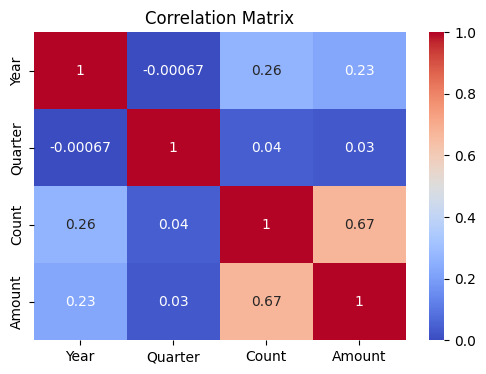

In [ ]:
# Chart - 6 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation calculation
corr = df[['Year', 'Quarter', 'Count', 'Amount']].corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

- A heatmap is best for showing relationships between numerical variables
- It visually represents correlation values (from -1 to +1)
- Helps quickly identify strong and weak relationships
- Useful for deeper data analysis and feature understanding

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- Count and Amount show a strong positive correlation
    - More transactions → higher total amount
- Year and Amount show positive correlation
    - Transactions are increasing over time
- Quarter correlation may be weak
    - Seasonal effect is present but not very strong

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:

- Strong Count–Amount relationship means:
    - Increasing number of users → directly increases revenue

Businesses can:

- Focus on user acquisition
- Increase transaction frequency
- Improve engagement

Negative Growth Insights:

- Weak correlation in some variables (e.g., Quarter) indicates:
- Inconsistent performance across periods

Possible reasons:

- Seasonal dependency
- Uneven marketing efforts

Impact:

- Revenue fluctuations
- Unstable growth

Justification:

- Correlation helps identify key drivers of growth
- usinesses should focus on:
    - Increasing transaction count
    - Maintaining consistent growth across quarters

#### Chart - 7

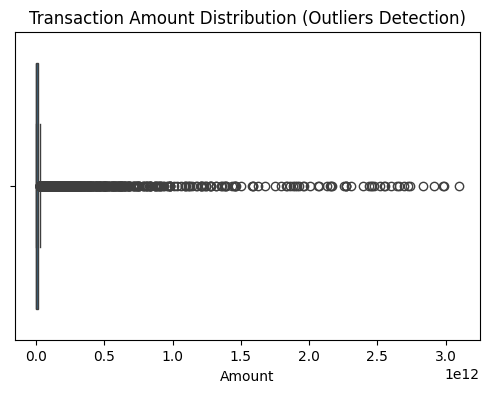

In [ ]:
# Chart - 7 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x=df['Amount'])

plt.title("Transaction Amount Distribution (Outliers Detection)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

- A boxplot is best for detecting:
- Outliers
    - Data distribution
    - Median & spread
    - It helps identify unusually high or low transaction values
- Very useful for financial datasets

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***